#### Simply press run, wait a bit and then scroll to "SKIP HERE FOR RESULTS" if you want to use our resistivity interpolations, spectral functions or self energy. No need to read the rest of the code, this is designed to be accessible to people who don't use Python.

### INITIALIZE:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.interpolate as interpolate
import time

### PARAMETERS/INITIAL ARRAYS:

In [5]:
t=1
tp=-0.430
tpp=0.005

k1=92
k2=92
Nexp=12
D=50

In [6]:
temparray=[0.0076628, 0.0086207, 0.0095785, 0.0105364 , 0.0114943, 0.0124521, 0.0134100, 0.0143678, 0.0153257, 0.0162835, 0.0172414, 0.0181992, 0.0191571, 0.0201149, 0.0210728, 0.0220307, 0.0229885, 0.0239464, 0.0249042, 0.0258621, 0.0268199, 0.0277778, 0.0287356, 0.0296935, 0.0306513, 0.0316092, 0.0325670, 0.0335349, 0.0344828, 0.0354406, 0.0363985, 0.0373563, 0.0383142, 0.0402299, 0.0421456, 0.0440613, 0.0459770, 0.0478927, 0.0498084, 0.0517241, 0.0536398, 0.0555556, 0.0574713, 0.0593870, 0.0613027, 0.0632184, 0.0651341, 0.0670498, 0.0689655, 0.0708812, 0.0727969, 0.0747126, 0.0766284]
tempnames=[('%.4f' %temp) for temp in temparray];

densities=[0.700,0.726,0.744,0.773,0.817,0.850];

In [7]:
sizev=2**Nexp 
sizee=k1*k2
sizek=k1

krange=np.linspace(0,2*np.pi-(2*np.pi/sizek),sizek)
vrange=np.linspace(-D,D-((2*D)/sizev),sizev) 

finalk1=np.zeros(k1*k2*(2**Nexp)).tolist()
finalk2=np.zeros(k1*k2*(2**Nexp)).tolist()
finalv=np.zeros(k1*k2*(2**Nexp)).tolist()

for i in range(sizek):            
    for j in range(sizek):
        for k in range(sizev):  
            m=k+sizev*(j+sizek*i)      
            finalk1[m]=krange[i]
            finalk2[m]=krange[j]
            finalv[m]=vrange[k]

DELTAomega=finalv[2]-finalv[1]

### IMPORTS:

In [9]:
class load:
    
    def __init__(self, filename):
        self.filename = filename
        lists = self._load_file()

        self.coeffRHOSYM = [[arr[0:5] for arr in sublist] for sublist in lists]
        self.coeffRHOASYM = [[arr[5:10] for arr in sublist] for sublist in lists]
        self.coeffRESYM = [[arr[10:16] for arr in sublist] for sublist in lists]
        self.coeffREASYM = [[arr[16:21] for arr in sublist] for sublist in lists]
        self.y0RHO = [[arr[21:22] for arr in sublist] for sublist in lists]
        self.y0RE = [[arr[22:23] for arr in sublist] for sublist in lists]
        self.mu = [[arr[23:24] for arr in sublist] for sublist in lists]

        # determine temperatures available in this file
        self.temps = np.array(temparray[-len(self.coeffRHOSYM):])

        del lists

    def _load_file(self):
        lists = []
        with open(self.filename, 'r') as f:
            contents = f.read().split('\n---\n')

        for list_section in contents:
            if list_section.strip():
                array_list = []
                lines = list_section.splitlines()

                for line in lines:
                    if not line.strip() or line.startswith("List") or line.startswith("Array"):
                        continue
                    array_list.append(np.fromstring(line, sep=' ', dtype=float))

                lists.append(array_list)

        return lists

    # turn coefficients back into polynomials:
    def poly_fits(self, x, k1k2):
        
        self.fitRHOSYM = []
        self.fitRHOASYM = []
        self.fitRESYM = []
        self.fitREASYM = []

        for i in range(len(self.temps)): 

            fitrhosym=[]
            fitrhoasym=[]
            fitresym=[]
            fitreasym=[]

            for j in range(k1k2):

                fitrhosym.append(p10(x, *self.coeffRHOSYM[i][j]))
                fitresym.append(pwithe(x, *self.coeffRESYM[i][j]))
                fitrhoasym.append(p9(x, *self.coeffRHOASYM[i][j]))
                fitreasym.append(p9(x, *self.coeffREASYM[i][j])) 

            self.fitRHOSYM.append(fitrhosym)
            self.fitRHOASYM.append(fitrhoasym)
            self.fitRESYM.append(fitresym)
            self.fitREASYM.append(fitreasym)
        

In [10]:
# Polynomials were fit over a small range in the center of the frequency domain (where most of the spectral weight is concentrated)

omeganew=[finalv[int((2**12)*i+int((2**12-1)/2)-20):int((2**12)*i+int((2**12-1)/2)+23)] for i in range(k1*k2)]
k1new=[finalk1[int((2**12)*i+int((2**12-1)/2)-20):int((2**12)*i+int((2**12-1)/2)+23)] for i in range(k1*k2)]
k2new=[finalk2[int((2**12)*i+int((2**12-1)/2)-20):int((2**12)*i+int((2**12-1)/2)+23)] for i in range(k1*k2)]

del finalv, finalk1, finalk2 # only middle of frequency parts are needed for this program

# scaled for numerical stability, scaled back later
omegac=0.04
x=np.array(omeganew[0])/omegac

def p9(x, b, d, f, h, j): 
    return b*x + d*x**3 + f*x**5 + h*x**7 + j*x**9

def p10(x, c, e, g, i, n): 
    return (c*x**2 + e*x**4 + g*x**6 + i*x**8 + n*x**10)

def pwithe(x, a, c, e, g, n,m ): 
    return np.exp(-a*x**2)*(c*x**2 + e*x**4 + g*x**6 + n*x**8 + m*x**10)

In [11]:
start_time = time.time()

datasets = {d: load(f"{int(d*1000)}Adata.txt") for d in densities}

end_time = time.time()
elapsed_time = end_time - start_time
print(elapsed_time) # in seconds

86.56833958625793


In [12]:
start_time = time.time()

for dataset in datasets.values():
    dataset.poly_fits(x, k1*k2)

end_time = time.time()
elapsed_time = end_time - start_time
print(elapsed_time) # in seconds

262.94162464141846


#### Various functions and components for reconstructing data:

In [14]:
def bandenergy(x, y, tp, tpp):
    return (-2*np.cos(x)-2*np.cos(y)-4*tp*np.cos(x)*np.cos(y)-2*tpp*(np.cos(2*x)+np.cos(2*y)))

bandenergyvec=np.vectorize(bandenergy)

In [15]:
bande=bandenergyvec(k1new,k2new,tp,tpp)
ve=omeganew-bande
veflat=np.concatenate(ve)

In [16]:
def depskx(kx,ky): 
    return 2*t*np.sin(kx) + 4*tp*np.sin(kx)*np.cos(ky) + 4*tpp*np.sin(2*kx)

ux = 1.0
uy = 0.0

def dF(x, tau): 
    if x/tau <= -20.0:
        return 0.0;
    elif x/tau >= 20.0:
        return 0.0
    else:
        return -1.0/ (2.0 * np.cosh(x / (2.0 * tau)))**2
    
dFvec=np.vectorize(dF)
depsvec=np.vectorize(depskx)

In [17]:
start_time = time.time()

for dataset in datasets.values():
    dataset.flatRHOSYM = [np.ravel(m) for m in dataset.fitRHOSYM]
    dataset.flatRHOASYM = [np.ravel(m) for m in dataset.fitRHOASYM]
    dataset.flatRESYM  = [np.ravel(m) for m in dataset.fitRESYM]
    dataset.flatREASYM = [np.ravel(m) for m in dataset.fitREASYM]

end_time = time.time()
elapsed_time = end_time - start_time
print(elapsed_time) 

6.021592855453491


### SPECTRAL FUNCTIONS ρG:
Reconstructing the spectral functions from our components:
$$\rho_G(\omega)=\frac{\rho_\Sigma}{(\omega+\mu-\epsilon_k-\Sigma')^2+(\pi\rho_\Sigma)^2}$$
For your convenience we also store the imaginary part of the Dyson self energy:
$$\Sigma''=-\pi \rho_\Sigma$$



In [19]:
for dataset in datasets.values():

    dataset.RHOG = []   # spectral function
    dataset.IMDyson = []   # imaginary part of Dyson self energy

    for i in range(len(dataset.temps)):
        refcn = (dataset.flatREASYM[i] + dataset.flatRESYM[i] + np.repeat(dataset.y0RE[i], len(ve[0])))
        rhfcn = (dataset.flatRHOASYM[i] + dataset.flatRHOSYM[i] + np.repeat(dataset.y0RHO[i], len(ve[0])))
        mu = dataset.mu[i][0][0]

        denom = (refcn**2 + (np.pi*rhfcn)**2 - 2*refcn*(veflat+mu)  + (veflat+mu)**2)

        rhoG = rhfcn/denom

        dataset.RHOG.append(rhoG)
        dataset.IMDyson.append(-np.pi*rhfcn)

### RESISTIVITY FROM SPECTRAL FUNCTIONS:

In [21]:
omegaflat = np.ravel(omeganew)
k1flat = np.ravel(k1new)
k2flat = np.ravel(k2new)
deps2 = depsvec(k1flat, k2flat)**2

In [22]:
for dataset in datasets.values():

    dataset.sigxx = []
    for i, tau in enumerate(dataset.temps):

        sigarr = (-dFvec(omegaflat,tau) * (dataset.RHOG[i]**2) * deps2)
        sigxxpart = sigarr.sum()
        sigxxfit = sigxxpart * ((2*np.pi)**2) * DELTAomega / (tau * k1 * k2)
        dataset.sigxx.append(sigxxfit)

    dataset.rhoxx = 1 / np.array(dataset.sigxx)

<font size="12">SKIP HERE FOR RESULTS</font>

### PLOT SPECTRAL FUNCTIONS AND IMAGINARY DYSON SELF ENERGY:

In [25]:
# Sets up easy kx and and ky selection:

k1flat = np.array(k1flat)
k2flat = np.array(k2flat)

kx_vals = np.unique(k1flat)
ky_vals = np.unique(k2flat)

Nkx = len(kx_vals)
Nky = len(ky_vals)

def to_grid(kx, ky, kx_vals, ky_vals):
    ikx = np.argmin(np.abs(kx_vals - kx))
    iky = np.argmin(np.abs(ky_vals - ky))
    return ikx, iky, kx_vals[ikx], ky_vals[iky]

def flat_index(ikx, iky, Nky, points=43):
    return (ikx * Nky + iky) * points

# easy temp selection:
def closest_temperature(user_temp, temp_array):
    temp_array=np.array(temp_array)
    i = np.argmin(np.abs(temp_array - user_temp))
    temp_snap = temp_array[i]
    return i, temp_snap

#### Spectral function plot example:

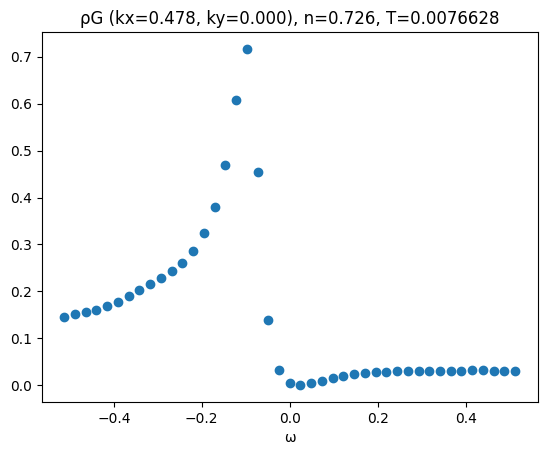

In [27]:
# Input your desired kx and ky value here:
desired_kx = 0.5
desired_ky = 0

# Takes you to the nearest available kx and ky:
ikx, iky, kx_snap, ky_snap = to_grid(desired_kx, desired_ky, kx_vals, ky_vals)
idx = flat_index(ikx, iky, Nky)

# Pick which density you want (options are 0.700, 0.726, 0.744, 0.773, 0.817, 0.850):
nval = 0.726
dataset = datasets[nval]

# Pick desired temperature (range is 0.0076628 to 0.0766284):
picktemp = 0.0077
itemp, temp_snap = closest_temperature(picktemp, dataset.temps)

# OPTIONAL spline fitting for visualization purposes. Keep OFF for sharpest spectral functions, will not interpolate well.
#spl = interpolate.InterpolatedUnivariateSpline(omeganew[0],dataset.RHOG[itemp][idx:idx+43]) 
#omega = np.linspace(omeganew[0][0], omeganew[0][-1], 500)
#plt.plot(omega, spl(omega))

# PLOT SPECTRAL FUNCTIONS:
plt.plot(omeganew[0],dataset.RHOG[itemp][idx:idx+43],'o')
plt.title(f"ρG (kx={kx_snap:.3f}, ky={ky_snap:.3f}), n={nval:.3f}, T={temp_snap}")
plt.xlabel("ω")
plt.show()

#### Self-energy plot example:

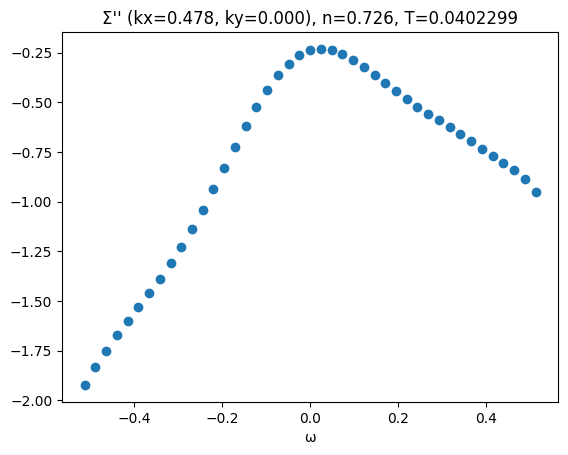

In [29]:
# Input your desired kx and ky value here:
desired_kx = 0.5
desired_ky = 0

# Takes you to the nearest available kx and ky:
ikx, iky, kx_snap, ky_snap = to_grid(desired_kx, desired_ky, kx_vals, ky_vals)
idx = flat_index(ikx, iky, Nky)


# PLOT Im(Σ):

# Pick which density you want (options are 0.700, 0.726, 0.744, 0.773, 0.817, 0.850):
nval = 0.726
dataset = datasets[nval]

# Pick desired temperature (range is 0.0076628 to 0.0766284):
picktemp = 0.04
itemp, temp_snap = closest_temperature(picktemp, dataset.temps)

# PLOT SPECTRAL FUNCTIONS:
plt.plot(omeganew[0],dataset.IMDyson[itemp][idx:idx+43],'o')
plt.title(f"Σ'' (kx={kx_snap:.3f}, ky={ky_snap:.3f}), n={nval:.3f}, T={temp_snap}")
plt.xlabel("ω")
plt.show()

### PLOT RESISTIVITIES:

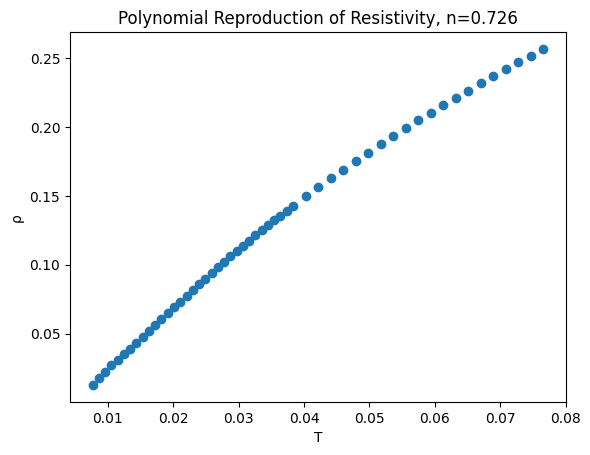

In [31]:
# one of the resistivity plots
# this is in dimensionless units, the units we used can be found in the paper

# Pick which density you want (options are 0.700, 0.726, 0.744, 0.773, 0.817, 0.850):
nval = 0.726
dataset = datasets[nval]

plt.plot(dataset.temps,dataset.rhoxx,'o')
plt.title(f"Polynomial Reproduction of Resistivity, n={nval:.3f}")
plt.ylabel("ρ")
plt.xlabel("T")
plt.show()

#### Resistivity Interpolation:

In [33]:
# interpolate all resistivities:

tvals = []
nvals = []
rhovals = []

for density, dataset in datasets.items():  
    for T, rho in zip(dataset.temps, dataset.rhoxx):
        tvals.append(T)
        nvals.append(density)
        rhovals.append(rho)

tvals = np.array(tvals)
nvals = np.array(nvals)
rhovals = np.array(rhovals)

# interpolation grid
X = np.linspace(tvals.min(), tvals.max())
Y = np.linspace(nvals.min(), nvals.max())

X, Y = np.meshgrid(X, Y)

interp = interpolate.LinearNDInterpolator(list(zip(tvals, nvals)), rhovals)
Z = interp(X, Y)

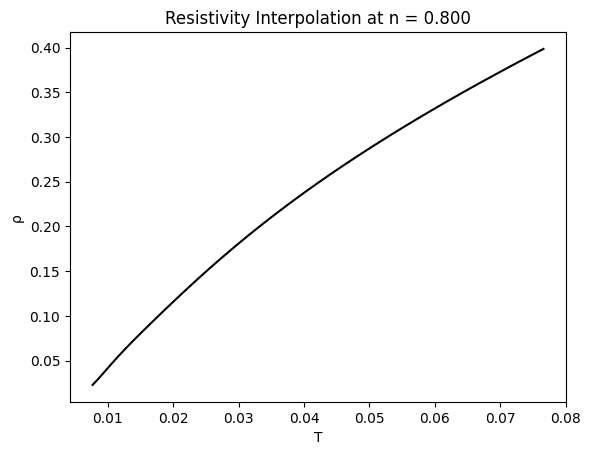

In [34]:
# Input your desired density here to plot interpolated density:

density=0.8

plt.plot(temparray,interp(temparray,density),'k-')
plt.title("Resistivity Interpolation at n = %1.3f" % density)
plt.ylabel("ρ")
plt.xlabel("T")
plt.show()